In [1]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
!curl https://zenodo.org/records/2603256/files/train.h5?download=1 -o toptag_train.h5
!curl https://zenodo.org/records/2603256/files/val.h5?download=1 -o toptag_val.h5
!curl https://zenodo.org/records/2603256/files/test.h5?download=1 -o toptag_test.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  990M  100  990M    0     0  18.6M      0  0:00:53  0:00:53 --:--:-- 20.3M  990M    2 28.6M    0     0  8367k      0  0:02:01  0:00:03  0:01:58 8367k 45  453M    0     0  17.7M      0  0:00:55  0:00:25  0:00:30 17.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  16.4M      0  0:00:20  0:00:20 --:--:-- 19.2M 0 16776    0     0  15000      0  6:25:58  0:00:01  6:25:57 14991
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  13.4M      0  0:00:24  0:00:24 --:--:-- 16.4M


In [2]:
fileIN_train = "toptag_train.h5"
fileIN_val = "toptag_val.h5"
fileIN_test = "toptag_test.h5"

f_train = h5py.File(fileIN_train)
# and see what it contains
print(list(f_train.keys()))

['table']


In [3]:
df_train = pd.read_hdf(fileIN_train, 'table')
df_val = pd.read_hdf(fileIN_val, 'table')
df_test = pd.read_hdf(fileIN_test, 'table')
df_train

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
375,474.071136,-250.347031,-223.651962,-334.738098,103.236237,-48.866222,-56.790775,-71.025490,105.255569,-55.415001,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
377,150.504532,120.062393,76.852005,-48.274265,82.257057,63.801739,42.754807,-29.454842,48.573559,36.763199,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
378,251.645386,10.427651,-147.573746,203.564880,104.147797,10.718256,-54.497948,88.101395,78.043213,5.724113,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
379,451.566132,129.885437,-99.066292,-420.984100,208.410919,59.033958,-46.177090,-194.467941,190.183304,54.069675,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
380,399.093903,-168.432083,-47.205597,-358.717438,273.691956,-121.926941,-30.803854,-243.088928,152.837219,-44.400204,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,206.171997,13.942102,114.328499,-171.001465,231.602356,19.010832,92.303848,-211.561432,95.868248,0.411594,...,0.0,0.0,0.0,0.0,1301.364624,48.551048,674.270081,-1098.891968,0,1
591,263.984161,-40.649391,-104.321312,239.065552,238.690689,8.786323,-101.236137,215.979828,126.197868,5.939164,...,0.0,0.0,0.0,0.0,1550.415405,-38.385075,-626.145813,1406.682983,0,1
592,61.417538,42.901291,43.947723,-0.436818,45.521763,31.723654,32.643845,-0.469300,44.801167,29.730831,...,0.0,0.0,0.0,0.0,654.942383,394.933441,467.778076,-162.717285,0,1
593,261.215302,12.780115,-132.699203,224.635300,224.066376,52.028233,-101.145271,193.050354,67.573616,17.166769,...,0.0,0.0,0.0,0.0,1100.826904,220.153702,-566.737549,901.328003,0,1


In [ ]:
it = df_train.iterrows()
index, row = next(it)
index

In [4]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model
# add masking to ignore attention computation of paddings

def get_num_valid_particles(X):
    X_ = (X > 0)
    X_ = torch.sum(X_, 1)
    for i in range(X_.shape[-1]):
        if X_[i] <= 0:
            break
    return i

class JetDataset(Dataset):

    def __init__(self, df):

        self.jets = list()
        self.labels = list()
        self.mask_indices = list()
        
        for index, row in df.iterrows():
            
            tensor = torch.tensor(row.values, dtype=torch.float)
            tensor_data = tensor[:-6].reshape(-1, 4)
    
            terminal_idx = get_num_valid_particles(tensor_data)
            
            self.jets.append(tensor_data)
            self.labels.append(tensor[-1].item())
            self.mask_indices.append(terminal_idx)
                
    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index], self.mask_indices[index]


In [5]:
# constituent of each jet is ordered from large to small energy
dataset_train = JetDataset(df_train)
dataset_val = JetDataset(df_val)
dataset_test = JetDataset(df_test)

0
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 

In [6]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)

    def forward(self, Q, K, mask_idx=None):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)

        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)
        
        A_pre = Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V)
        
        if mask_idx is not None:
            mask = torch.full((200,200), -float('inf'))
            mask[:mask_idx, :mask_idx] = 0
            A_pre += mask
            
        A = torch.softmax(A_pre, 2)
            
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True,):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X, mask_idx):
        return self.mab(X, X, mask_idx)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.enc = nn.Sequential(
                SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias),
              )
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden, dim_output, bias = bias),
        )

    def forward(self, X, mask_idx=None):
        X_ = self.pool(self.enc(X, mask_idx).transpose(1, 2)).squeeze(dim=-1)
        X_ = self.fc(self.norm(X_))
        return X_

In [7]:
torch.cuda.is_available()

True

In [8]:
# define model, dataloaders, optimizers, etc.
device = "cuda" if torch.cuda.is_available() else "cpu"

dim_in = 4
dim_output = 1
num_particles_per_jet = 200
num_heads = 2
dim_hidden = 16*num_heads
bias = True
model = SetTransformer(dim_in, dim_output, num_particles_per_jet, num_heads=num_heads, dim_hidden=dim_hidden, bias=bias).to(device)


'''
dataset_size = len(dataset)  # use a smaller number of datapoints for debugging
num_train = int(dataset_size * 0.8)
num_test = int(dataset_size * 0.1)
num_val = dataset_size - num_train - num_test

subset_indices_train = list(range(num_train))
subset_indices_val = list(range(num_train,num_train+num_val))
subset_indices_test = list(range(num_train+num_val, dataset_size))

train_subset = Subset(dataset, subset_indices_train)
val_subset = Subset(dataset, subset_indices_val)
test_subset = Subset(dataset, subset_indices_test)
'''

train_dataloader = DataLoader(dataset_train, batch_size=512, shuffle=True)
val_dataloader = DataLoader(dataset_val, batch_size=512, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=512, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

m = nn.Sigmoid()
mm = nn.BCELoss()

In [9]:
# training loop

epochs = 100
training_losses = []
eval_losses = []

for epoch in range(epochs):

    losses = []

    model.train()
    for batch in iter(train_dataloader):

        X, y, mask_idx = batch
        
        X = X.to(device)
        y = y.to(device)
        mask_idx = mask_idx.to(device)
        
        output = model(X, mask_idx).squeeze(dim=1).to(torch.float64)

        loss = mm(m(output), y)

        losses.append(loss.detach().cpu().item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, train loss {sum(losses)/len(losses)}")
    training_losses.append(sum(losses)/len(losses))
    
    model.eval()
    val_losses = []
    with torch.no_grad():

        for batch in iter(val_dataloader):

            X, y = batch
            
            X = X.to(device)
            y = y.to(device)
        
            output = model(X).squeeze(dim=1).to(torch.float64)

            loss = mm(m(output), y)

            val_losses.append(loss.detach().cpu().item())

    print(f"Epoch {epoch}, val loss {sum(val_losses)/len(val_losses)}")
    eval_losses.append(sum(val_losses)/len(val_losses))
    

Epoch 0, train loss 0.6253505734656062
Epoch 0, val loss 0.6065821391061952
Epoch 1, train loss 0.600493068413367
Epoch 1, val loss 0.5923099189790316
Epoch 2, train loss 0.5871846974098973
Epoch 2, val loss 0.5791512849174411
Epoch 3, train loss 0.5752178377541888
Epoch 3, val loss 0.5697656810767575
Epoch 4, train loss 0.5673885371392944
Epoch 4, val loss 0.5633740968510558
Epoch 5, train loss 0.563012280784149
Epoch 5, val loss 0.559907661557635
Epoch 6, train loss 0.5595122110471941
Epoch 6, val loss 0.5619182795933074
Epoch 7, train loss 0.5571184996102355
Epoch 7, val loss 0.5565118935335895
Epoch 8, train loss 0.5541262646148449
Epoch 8, val loss 0.5592034165729285
Epoch 9, train loss 0.5514501072446443
Epoch 9, val loss 0.5644153633469684
Epoch 10, train loss 0.5490615731929981
Epoch 10, val loss 0.5446874226638887
Epoch 11, train loss 0.5462087781373933
Epoch 11, val loss 0.5469718212002557
Epoch 12, train loss 0.5431022256904362
Epoch 12, val loss 0.54415341701531
Epoch 13, t

KeyboardInterrupt: 

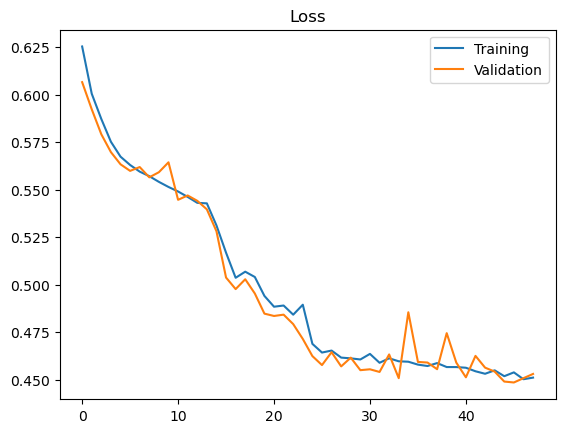

In [10]:
# loss plot

import matplotlib.pyplot as plt
fig,axes = plt.subplots(1)

axes.plot(training_losses)
axes.plot(eval_losses)
axes.legend(["Training", "Validation"])
axes.set_title("Loss")

fig.show()

Test set loss: 0.4605894150005107
Test accuracy: 0.7570148514851485


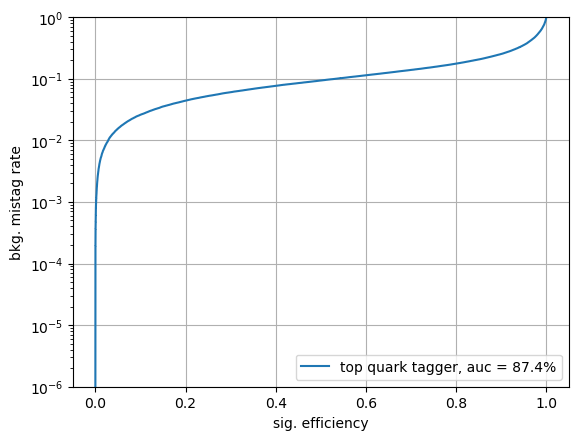

In [11]:
# testing on test set

model.eval()

test_losses = []
test_logits = []
test_labels_true = []
test_num_correct = 0
with torch.no_grad():

    for batch in iter(test_dataloader):

        X, y = batch
        
        X = X.to(device)
        y = y.to(device)
        
        output = model(X).squeeze(dim=1).to(torch.float64)

        predicted_labels = (output >= 0.5)

        loss = mm(m(output), y)

        test_labels_true.extend(list(y.to(torch.long).detach().cpu().numpy()))
        test_logits.extend(list(output.detach().cpu().numpy()))
        test_losses.append(loss.item())
        test_num_correct += torch.sum(y == predicted_labels).item()

print(f"Test set loss: {sum(test_losses)/len(test_losses)}")
print(f"Test accuracy: {test_num_correct / len(dataset_test)}")

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

df = pd.DataFrame()
fpr = {}
tpr = {}
auc1 = {}

plt.figure()

fpr, tpr, threshold = roc_curve(np.array(test_labels_true), np.array(test_logits))

auc1 = auc(fpr, tpr)

plt.plot(tpr,fpr,label='%s tagger, auc = %.1f%%'%("top quark",auc1*100.))

plt.semilogy()
plt.xlabel("sig. efficiency")
plt.ylabel("bkg. mistag rate")
plt.ylim(0.000001,1)
plt.grid(True)
plt.legend(loc='lower right')
plt.show()


In [12]:
# Saving model
PATH = "./1layer_set_transformer_topquarktag_reducedmlp_3heads.pt"
torch.save(model.state_dict(), PATH)

In [33]:
import seaborn as sns

torch.Size([64, 4])
Linear(in_features=4, out_features=64, bias=True)


<Axes: >

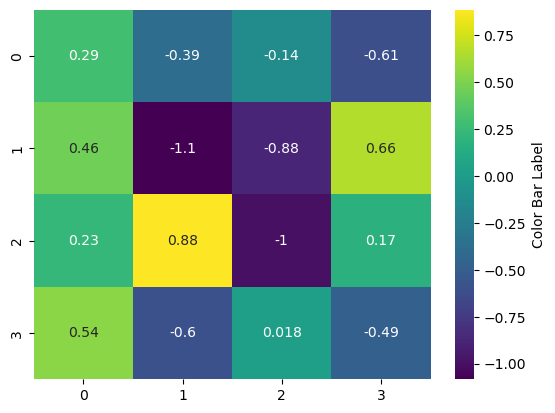